# Install Dependencies and Import

In [ ]:
# Install Dependencies
%pip install -q --upgrade numerapi numerai-tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from datetime import timedelta
import time

from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution, neutralize

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Functions

In [65]:
# Общая информация о датафрейме
def describe_df(df: pd.DataFrame):

    n_rows, n_cols = df.shape
    missing_total = df.isnull().sum().sum()
    min_era = df['era'].min()
    max_era = df['era'].max()
    total_eras = df['era'].nunique()

    print(f"Shape: {n_rows} × {n_cols}")
    print(f"Miss: {missing_total}")
    print(f"Eras: {min_era}-{max_era} ({total_eras})")

In [64]:
def analyze_missing(train: pd.DataFrame, feature_set: list, top_k: int, plot=True):

    # === Missing by Era ===
    missing_eras = train.groupby('era')[feature_set].apply(lambda x: (x == 2).all(axis=0))
    missing_eras = missing_eras.reset_index()
    missing_eras['miss_count'] = missing_eras[feature_set].sum(axis=1)

    eras_with_missing = missing_eras[missing_eras['miss_count'] > 0]
    
    last_missing_era = eras_with_missing['era'].max()
    all_eras_sorted = sorted(train['era'].unique())
    
    cutoff_idx = all_eras_sorted.index(last_missing_era)
    cutoff_era = all_eras_sorted[cutoff_idx + 1]

    # === Missing by Features ===
    missing_features = missing_eras[feature_set].sum(axis=0)
    missing_features = pd.DataFrame(missing_features, columns=['miss_count'])
    missing_features['%'] = missing_features['miss_count'] / len(missing_eras) * 100

    missing_features = missing_features.sort_values('%', ascending=False)
    top_missing_features = missing_features.head(top_k)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Plot Missing by Era
        axes[0].bar(missing_eras['era'], missing_eras['miss_count'], color='purple', width=1)
        axes[0].set_title("Missing by Eras")
        axes[0].set_xlabel("Eras")
        axes[0].set_ylabel("Missing")
        axes[0].grid(True, alpha=0.3)

        if cutoff_era:
            axes[0].axvline(x=last_missing_era, color='red', linestyle='--', label=f'First era without missing: {cutoff_era}')
            axes[0].legend()

        # Plot Missing by Features
        axes[1].barh(top_missing_features.index, top_missing_features['miss_count'], color='salmon', height=0.8)
        axes[1].set_title(f"Top-{top_k} Missing by Features")
        axes[1].set_xlabel("Count of Eras with Full Missing")
        axes[1].set_ylabel("Features")
        # axes[1].set_yticks([])  # Убираем ВСЕ метки на оси Y
        axes[1].set_yticks(range(len(top_missing_features)))
        axes[1].set_yticklabels(top_missing_features.index)
        axes[1].invert_yaxis()
        axes[1].grid(True, axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

    return cutoff_era, missing_features

# Loading Numerai Datasets  

In [ ]:
# Initialize NumerAPI
napi = NumerAPI()

# Get current active round for Numerai Tournament
current_round = napi.get_current_round()
print("CURRENT ROUND:", current_round)
print('')

# List all available datasets
all_datasets = napi.list_datasets()

# Extract unique data versions
dataset_versions = list(set(d.split('/')[0] for d in all_datasets))
DATA_VERSION = max(dataset_versions)  # Use latest version
print("AVAILABLE DATA VERSIONS:\n", sorted(dataset_versions))
print('')

# List all files from the latest data version
print(f"FILES IN VERSION {DATA_VERSION}:")
current_version_files = [f for f in all_datasets if f.startswith(DATA_VERSION)]
for f in sorted(current_version_files):
    print(f"  {f}")

In [ ]:
napi.download_dataset(f"{DATA_VERSION}/features.json")
napi.download_dataset(f"{DATA_VERSION}/train.parquet")
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
napi.download_dataset(f"{DATA_VERSION}/meta_model.parquet")

# Feature Metadata  
  
В версии 'v5.2' 18 наборов признаков и 41 таргет.  
- К таргетам вернусь на стадии создания ансамбля.  

**Feature Sets:**
- Общие наборы: 'small', 'medium', 'all'. Включают в себя признаки из разных наборов.
- 'v2_equivalent_features' и 'v3_equivalent_features' - для совместимости со старыми версиями данных. Но признаки из этих наборов есть и в тематических.  
- 'fncv3_features' - специальный набор фичей, созданный для 'feature neutral correlation version 3'.
- Тематические наборы: 'intelligence', 'charisma', 'strength', 'dexterity', 'constitution', 'wisdom', 'agility', 'serenity', 'sunshine', 'rain', 'midnight', 'faith'.   
  
<br>

Оптимальный набор для старта - Medium (780 признаков).  
Сохраняю словарь `medium_dict` для нейтрализации признаков.

In [56]:
# === LOADING METADATA ===
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

grouped_sets = {}
for size_set in ['small', 'medium', 'all']:
        grouped_sets[size_set] = {}
        for k, v in feature_sets.items():
                if k not in ['small', 'medium']:
                    grouped_sets[size_set][k] = list(set(feature_sets[size_set]) & set(feature_sets[k]))

medium_dict = grouped_sets['medium']  # For neutralize features
medium_set = medium_dict['all']  # List of features - Medium

grouped_sets_df = pd.DataFrame(grouped_sets)
grouped_sets_df = grouped_sets_df.applymap(lambda x: len(x)).sort_values(by='all', ascending=False)
display(grouped_sets_df)

,small,medium,all
all,42,780,2748
v3_equivalent_features,15,400,1000
rain,20,0,666
fncv3_features,8,400,400
faith,0,75,372
constitution,2,134,335
sunshine,5,130,325
v2_equivalent_features,7,304,304
charisma,3,116,290
midnight,0,122,244


# Uploading Datasets

## Train


In [57]:
# Load dataset with medium features
train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era", "target"] + medium_set)
train['era'] = train['era'].astype(int)
describe_df(train)

# Drop rows where target=NaN
display(train[train.isna().any(axis=1)])
train = train.dropna(subset=['target'])
describe_df(train)

Shape: 2746270 × 782
Miss: 2
Eras: 1-574 (574)


,era,target,feature_vivisectional_latvian_dispensator,feature_unparental_reheated_chemnitz,feature_indescribable_multiped_neoclassicism,feature_enceinte_awry_zincograph,feature_axial_solutrean_pry,feature_clerkly_memoriter_crematory,feature_overgreat_unblamed_hyperaemia,feature_tatar_porphyritic_bogey,...,feature_phenotypical_benedictional_interposal,feature_choreic_sterilized_lagune,feature_pericentric_unaccented_coldslaw,feature_interlocking_unextended_infield,feature_canonistic_disallowable_counterbore,feature_reconditioned_underglaze_girasol,feature_craggiest_dopy_conversazione,feature_unpiloted_sleetier_belial,feature_whatsoever_muskier_dangler,feature_pelting_goatish_electrowinning
id,,,,,,,,,,,,,,,,,,,,,
n1b7cb7d2e61e62f,1,NaN,2,2,2,2,1,1,4,1,...,2,1,2,4,2,4,2,1,1,4
n1bbddbf04570ab8,1,NaN,2,2,2,2,0,1,4,0,...,0,4,0,1,0,2,2,0,3,4


Shape: 2746268 × 782
Miss: 0
Eras: 1-574 (574)


### Target  
  
`Target` (float32) распределён по 5 неравным бинам: 0, 0.25, 0.5, 0.75, 1.0  
Это распределение относится как ко всему датасету, так и для каждой эры отдельно.



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

train['target'].plot(kind='hist', title='Target', xlabel='Value', density=True, bins=50, ax=ax1)
train.groupby('era')['target'].value_counts(normalize=True).unstack(fill_value=0).plot(ax=ax2)

ax2.set_title("Target Distribution by Era")
plt.show()

### Analysis of Missing Values

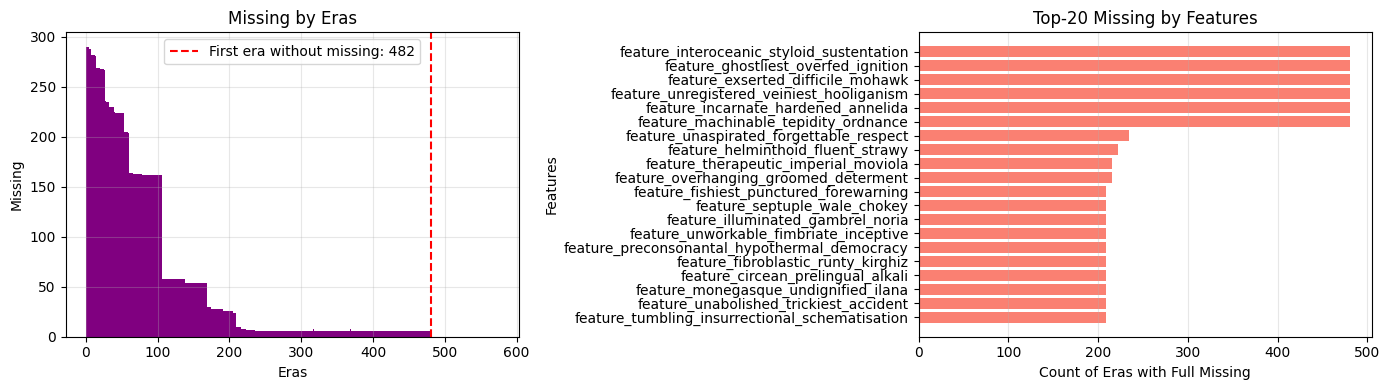

,miss_count,%
feature_interoceanic_styloid_sustentation,481,83.797909
feature_ghostliest_overfed_ignition,481,83.797909
feature_exserted_difficile_mohawk,481,83.797909
feature_unregistered_veiniest_hooliganism,481,83.797909
feature_incarnate_hardened_annelida,481,83.797909
feature_machinable_tepidity_ordnance,481,83.797909
feature_unaspirated_forgettable_respect,235,40.940767
feature_helminthoid_fluent_strawy,222,38.675958
feature_therapeutic_imperial_moviola,215,37.456446
feature_overhanging_groomed_determent,215,37.456446


In [59]:
cutoff_era, missing_features = analyze_missing(train, medium_set, top_k=20, plot=True)
missing_features.head(10)

In [60]:
# === Removing Features with Missing & First Eras ===
excluded_features_1 = set(missing_features[missing_features['%'] > 80].index)
first_era = 250

medium_set_clean = list(set(medium_set) - excluded_features_1)
train_clean = train[train.era >= first_era][['era', 'target'] + medium_set_clean]

print(f"Remaining Features: {len(medium_set_clean)}/{len(medium_set)} ({len(excluded_features_1)})")
print(f"Clean Eras: {train_clean['era'].min()}-{train_clean['era'].max()} ({train_clean['era'].nunique()})")

Remaining Features: 774/780 (6)
Clean Eras: 250-574 (325)


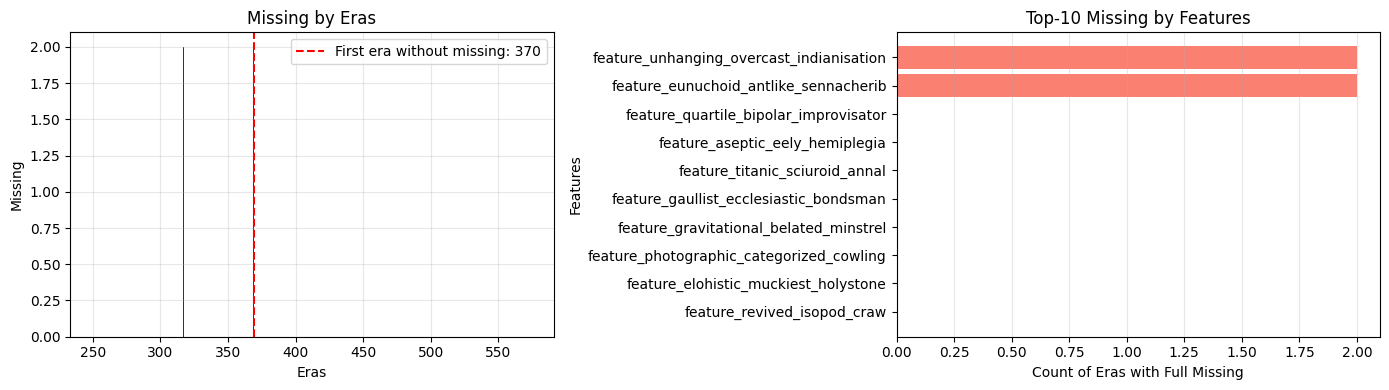

,miss_count,%
feature_unhanging_overcast_indianisation,2,0.615385
feature_eunuchoid_antlike_sennacherib,2,0.615385
feature_quartile_bipolar_improvisator,0,0.000000
feature_aseptic_eely_hemiplegia,0,0.000000
feature_titanic_sciuroid_annal,0,0.000000
feature_gaullist_ecclesiastic_bondsman,0,0.000000
feature_gravitational_belated_minstrel,0,0.000000
feature_photographic_categorized_cowling,0,0.000000
feature_elohistic_muckiest_holystone,0,0.000000
feature_revived_isopod_craw,0,0.000000


In [61]:
cutoff_era, missing_features = analyze_missing(train_clean, medium_set_clean, top_k=5, plot=True)
missing_features.head(5)

In [62]:
# === Removing Features with Missing ===
excluded_features_2 = set(missing_features[missing_features['%'] > 0].index)

medium_set_clean = list(set(medium_set_clean) - excluded_features_2)
train_clean = train_clean[['era', 'target'] + medium_set_clean]

print(f"Remaining Features: {len(medium_set_clean)}/{len(medium_set)} ({len(excluded_features_1) + len(excluded_features_2)})")

Remaining Features: 772/780 (8)


In [63]:
missing_eras = train_clean.groupby('era')[medium_set_clean].apply(lambda x: (x == 2).all(axis=0))
eras_with_missing = missing_eras[medium_set_clean].sum(axis=1).sum()
print(f"Eras with missing: {eras_with_missing}")

Eras with missing: 0


In [76]:
# Update 'medium_dict
excluded_features = excluded_features_1 | excluded_features_2
medium_dict_clean = {key: set(value) - excluded_features for key, value in medium_dict.items()}

del medium_dict_clean['rain']  # Emty

for k, v in medium_dict_clean.items():
    print(k, len(v))

all 772
v2_equivalent_features 304
v3_equivalent_features 400
fncv3_features 400
intelligence 14
charisma 116
strength 54
dexterity 21
constitution 134
wisdom 56
agility 56
serenity 34
sunshine 130
rain 0
midnight 122
faith 69


In [81]:
print("=== TRAIN CLEAN ===")
print(f"Rows: {train_clean.shape[0]}")
print(f"Columns: {train_clean.shape[1]}")
print(f"Feature: {len(medium_set_clean)}")
print(f"Eras: {train_clean['era'].min()}-{train_clean['era'].max()} ({train_clean['era'].nunique()})")

=== TRAIN CLEAN ===
Rows: 1638585
Columns: 776
Feature: 772
Eras: 250-574 (325)


## Validation

In [86]:
# Load dataset
validation = pd.read_parquet(f"{DATA_VERSION}/validation.parquet", columns=["era", "target", "data_type"] + medium_set_clean)
validation['era'] = validation['era'].astype(int)

validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

describe_df(validation)
display(validation.head(1))

Shape: 3834736 × 774
Miss: 0
Eras: 575-1192 (618)


,era,target,feature_vivisectional_latvian_dispensator,feature_unparental_reheated_chemnitz,feature_indescribable_multiped_neoclassicism,feature_enceinte_awry_zincograph,feature_axial_solutrean_pry,feature_clerkly_memoriter_crematory,feature_overgreat_unblamed_hyperaemia,feature_tatar_porphyritic_bogey,...,feature_phenotypical_benedictional_interposal,feature_choreic_sterilized_lagune,feature_pericentric_unaccented_coldslaw,feature_interlocking_unextended_infield,feature_canonistic_disallowable_counterbore,feature_reconditioned_underglaze_girasol,feature_craggiest_dopy_conversazione,feature_unpiloted_sleetier_belial,feature_whatsoever_muskier_dangler,feature_pelting_goatish_electrowinning
id,,,,,,,,,,,,,,,,,,,,,
n000101811a8a843,575,0.5,0,2,4,4,1,4,4,0,...,2,4,2,2,2,4,2,0,4,2


### Meta Model  

Добавлю к 'validation' столбец 'numerai_meta_model' для рассчёта 'MMC.
   
- **MMC (Meta Model Contribution)** — мера того, насколько уникально и добавочно модель улучшает 'Numerai Meta Model'.

In [89]:
meta_model = pd.read_parquet(f"{DATA_VERSION}/meta_model.parquet")
meta_model['era'] = meta_model['era'].astype(int)

describe_df(meta_model)
meta_model.head(1)

Shape: 388414 × 3
Miss: 0
Eras: 1133-1192 (60)


,era,data_type,numerai_meta_model
id,,,
n0001a161ef7f066,1133,validation,0.59803


In [90]:
# Join numerai_meta_model and validation
validation = validation.join(meta_model["numerai_meta_model"], how="left")
validation.rename(columns={"numerai_meta_model": "meta_model"}, inplace=True)

# Сколько строк в каждом датафрейме
print(f"Rows Validation: {len(validation)}")
print(f"Rows MetaModel: {len(meta_model)}")

# Matching ID (indexes)
common_ids = validation.index.intersection(meta_model.index)
print(f"Matching ID: {len(common_ids)}")

Rows Validation: 3834736
Rows MetaModel: 388414
Matching ID: 388414


# Train / Val

In [94]:
# === PURGE & EMBARGO ===
PURGE = 2 
EMBARGO = 2 

unique_train_eras = sorted(train['era'].unique())
unique_val_eras = sorted(validation['era'].unique())

# Removing the latest `PURGE` eras from Train
purge_eras = [int(x) for x in unique_train_eras[-PURGE:]]
train_clean = train_clean[~train_clean['era'].isin(purge_eras)]

# Skipping the first `EMBARGO` eras from Validation
embargo_eras = [int(x) for x in unique_val_eras[:EMBARGO]]
val_clean = validation[~validation['era'].isin(embargo_eras)]

summary_data = {
    'Dataset': ['Train', 'Validation'],
    'Rows': [train_clean.shape[0], val_clean.shape[0]],
    'Cols': [train_clean.shape[1], val_clean.shape[1]],
    'Min Era': [train_clean.era.min(), val_clean.era.min()],
    'Max Era': [train_clean.era.max(), val_clean.era.max()],
    # 'Purge/Embargo': [purge_eras, embargo_eras],
    'Purge': [purge_eras, None],
    'Embargo': [None, embargo_eras],
    'N Eras': [train_clean['era'].nunique(), val_clean['era'].nunique()],  
}

summary_df = pd.DataFrame(summary_data).set_index('Dataset')
display(summary_df)

,Rows,Cols,Min Era,Max Era,Purge,Embargo,N Eras
Dataset,,,,,,,
Train,1627390,774,250,572,"[573, 574]",None,323
Validation,3823506,775,577,1192,None,"[575, 576]",616


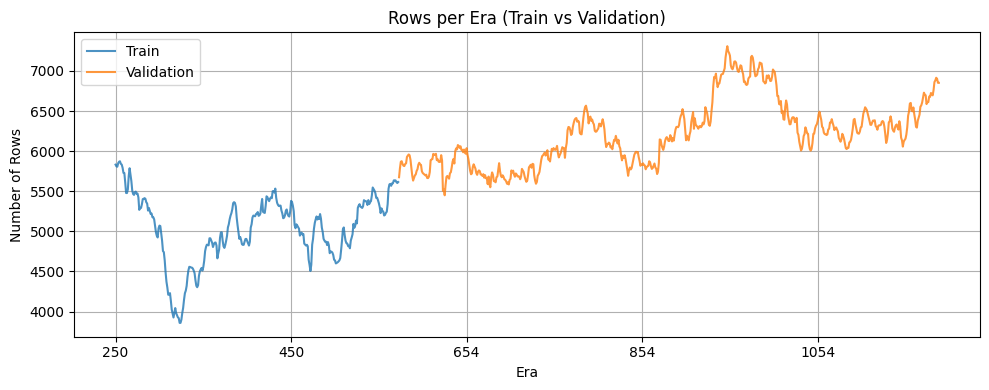

In [95]:
# === Distribution Rows by Era ===
train_era_count = train_clean.groupby("era").size()
val_era_count = val_clean.groupby("era").size()

combined = pd.concat([train_era_count, val_era_count], axis=1, keys=['Train', 'Validation'])
combined.index = pd.Categorical(combined.index, categories=sorted(combined.index), ordered=True)
combined = combined.sort_index()

ax = combined.plot(
    kind='line',
    figsize=(10, 4),
    title="Rows per Era (Train & Validation)",
    xlabel="Era",
    ylabel="Number of Rows", alpha=0.8, grid=True
)

ax.legend()
plt.tight_layout()
plt.show()

# Saving Data  

In [96]:
train_clean.to_parquet("/content/drive/MyDrive/Colab Notebooks/Step_1/train_medium.parquet")
val_clean.to_parquet("/content/drive/MyDrive/Colab Notebooks/Step_1/val_medium.parquet")

with open("/content/drive/MyDrive/Colab Notebooks/Step_1/grouped_set_medium.pkl", "wb") as f:
    pickle.dump(medium_dict_clean, f)